Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [11]:
import numpy as np
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# Add parent directory to path to import local modules
sys.path.insert(0, str(Path.cwd().parent))

from src.core.SEIRSParameters import*
from src.core.solvers import*
from src.core.utils import*

In [3]:
output_dir = Path.cwd().parent / "outputs" / "figures" / "nb2"
output_dir.mkdir(parents=True, exist_ok=True)

Global parameters

In [4]:
n = 50 # grid size (number of nodes in each dimension); we'll use a smaller value for quick implementtion

# diffusion rates
DS = 0.1
DE = np.exp(-9)
DI = np.exp(-9)
DR = 0.01

ALPHA = 0.01
SIGMA = 0.33

BETA_0 = 0.05
GAMMA_0 = 0.15

GAMMA_COEFF = BETA_COEFF = 0.1


POPULATION_DENSITY = 1.0 # N
OMEGA = 1.0 # space volume in 2D 
M=n*n

baseParams = SEIRSParameters(
    dS=DS,
    dE=DE,
    dI=DI,
    dR=DR,
    N=POPULATION_DENSITY,
    grid_size=n,
    alpha=ALPHA,
    sigma=SIGMA,
    beta_0=BETA_0,
    gamma_0=GAMMA_0,
    gamma_coeff=GAMMA_COEFF,
    beta_coeff=BETA_COEFF
)

In [5]:
# Gaussian parameters
R_GAMMA = 0.1 # radius/width
R_BETA = 0.15
C_GAMMA = (0.25, 0.25) # center
C_BETA = (0.75, 0.75)

In [6]:
beta_field = baseParams.beta_field(mu=C_BETA, sigma=R_BETA)

X,Y = baseParams.make_grid()
gamma_field = np.full_like(X, baseParams.gamma_0) # so gamma is constant
    
print(f"gamma_field : \n{gamma_field}")


gamma_field : 
[[0.15 0.15 0.15 ... 0.15 0.15 0.15]
 [0.15 0.15 0.15 ... 0.15 0.15 0.15]
 [0.15 0.15 0.15 ... 0.15 0.15 0.15]
 ...
 [0.15 0.15 0.15 ... 0.15 0.15 0.15]
 [0.15 0.15 0.15 ... 0.15 0.15 0.15]
 [0.15 0.15 0.15 ... 0.15 0.15 0.15]]


This makes gamma constant = gamma_0 accross all the grid.
Now let's define the other parameters.

In [23]:
gamma_0 = baseParams.gamma_0

# Step 2: patch widths to sweep 
sigma_beta_range = np.arange(1e-3, 2.0+1e-3, 1e-3)

# Step 4: principled epsilon targets, spanning well below/above 1
epsilon_targets = np.array([0.1, 0.3, 1, 3, 10])

# d depends on BOTH epsilon and sigma_beta 
# shape: (len(epsilon_targets), len(sigma_beta_range))
d_grid = gamma_0 * (epsilon_targets[:, None] * sigma_beta_range[None, :])**2

In [24]:
def compute_R0(params:SEIRSParameters, beta_field, gamma_field):
    mu_star = compute_mu_star(params=params, beta_field=beta_field, gamma_field=gamma_field)
    return baseParams.N/mu_star

# ============================================================
# Steps 3-4: epsilon grid -> d grid
# d depends on BOTH epsilon and sigma_beta, so this is a lookup
# ============================================================
 
def d_from_epsilon(epsilon, sigma_beta, gamma0):
    return gamma0 * (epsilon * sigma_beta) ** 2

def run_beta_sweep(
        params: SEIRSParameters,
        epsilon_targets,
        A_beta_range=np.linspace(0.0, 1.0, 6),
        sigma_beta_range=np.linspace(0.2,1.0,5)):
    
    X,Y = make_grid(n)
    rows = []
    
    for epsilon in epsilon_targets:

        for sigma_beta in sigma_beta_range:

            # d depends on this (epsilon, sigma_beta) pair, recomputed every time
            d = d_from_epsilon(epsilon, sigma_beta, params.gamma_0)
            
            for A_beta in A_beta_range:

                # redefine parameters for dE=dI=d
                newParams=SEIRSParameters(
                        dS=DS,
                        dE=d,
                        dI=d,
                        dR=DR,
                        N=POPULATION_DENSITY,
                        grid_size=n,
                        alpha=ALPHA,
                        sigma=SIGMA,
                        beta_0=A_beta,
                        gamma_0=GAMMA_0,
                        gamma_coeff=GAMMA_COEFF,
                        beta_coeff=BETA_COEFF
                    )
                
                beta_field = params.beta_field(constant=A_beta, mu=C_BETA, sigma=sigma_beta)
                R0 = compute_R0(params=newParams, beta_field=beta_field, gamma_field=gamma_field)

                rows.append(
                    dict(
                        epsilon=epsilon,
                        d=d,
                        sigma_beta=sigma_beta,
                        A_beta=A_beta,
                        R0=R0,
                        mass_proxy=A_beta*sigma_beta **2
                    )
                )
    return pd.DataFrame(rows)

# ============================================================
# Crossover detection
# For each epsilon, fit R0 against A_beta alone, and against
# A_beta * sigma_beta^2 alone, compare which fits better.
# ============================================================
 
def fit_r2(x, y):
    if np.allclose(x, x[0]):
        return np.nan  # degenerate, cannot fit a slope
    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
 
 
def crossover_table(df: pd.DataFrame):
    results = []
    for epsilon, g in df.groupby("epsilon"):
        r2_peak = fit_r2(g["A_beta"].values, g["R0"].values)
        r2_mass = fit_r2(g["mass_proxy"].values, g["R0"].values)
        results.append(dict(epsilon=epsilon, r2_vs_A_beta=r2_peak,
                             r2_vs_A_beta_sigma2=r2_mass,
                             regime="peak" if r2_peak > r2_mass else "mass"))
    return pd.DataFrame(results).sort_values("epsilon")


In [13]:
output_table_dir = Path.cwd().parent / "outputs" / "tables" / "nb2"
output_table_dir.mkdir(parents=True, exist_ok=True)

In [25]:
df = run_beta_sweep(
    params=baseParams,
    epsilon_targets=epsilon_targets
)

df.to_csv(output_table_dir / "beta_sweep_resuls.csv", index=False)

In [21]:
def plot_peak_law_collapse(df, save_path=None):
    """
    Step 5 check: for each epsilon, R0 vs A_beta, one line per sigma_beta.
    Low epsilon: lines should collapse onto one curve (peak dominated,
    width does not matter). High epsilon: lines should fan out.
    """
    epsilons = sorted(df["epsilon"].unique())
    n = len(epsilons)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
    axes = np.atleast_1d(axes)

    cmap = plt.cm.viridis
    for ax, eps in zip(axes, epsilons):
        sub = df[df["epsilon"] == eps]
        sigma_vals = sorted(sub["sigma_beta"].unique())
        for i, sig in enumerate(sigma_vals):
            line = sub[sub["sigma_beta"] == sig].sort_values("A_beta")
            color = cmap(i / max(len(sigma_vals) - 1, 1))
            ax.plot(line["A_beta"], line["R0"], marker="o", ms=3,
                     color=color, label=f"sig={sig:.2f}")
        ax.set_title(f"epsilon = {eps:.2g}")
        ax.set_xlabel("A_beta")
    axes[0].set_ylabel("R0")
    axes[-1].legend(fontsize=6, loc="best")
    fig.suptitle("R0 vs A_beta, by sigma_beta (collapse = peak dominated)")
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150)
    return fig


def plot_mass_law_collapse(df, save_path=None):
    """
    Step 6 check: for each epsilon, R0 vs sigma_beta, one line per A_beta.
    Low epsilon: lines should be roughly flat (width does not matter).
    High epsilon: lines should rise, roughly ~ sigma_beta^2.
    """
    epsilons = sorted(df["epsilon"].unique())
    n = len(epsilons)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
    axes = np.atleast_1d(axes)

    cmap = plt.cm.plasma
    for ax, eps in zip(axes, epsilons):
        sub = df[df["epsilon"] == eps]
        a_vals = sorted(sub["A_beta"].unique())
        for i, a in enumerate(a_vals):
            line = sub[sub["A_beta"] == a].sort_values("sigma_beta")
            color = cmap(i / max(len(a_vals) - 1, 1))
            ax.plot(line["sigma_beta"], line["R0"], marker="o", ms=3,
                     color=color, label=f"A={a:.2f}")
        ax.set_title(f"epsilon = {eps:.2g}")
        ax.set_xlabel("sigma_beta")
    axes[0].set_ylabel("R0")
    axes[-1].legend(fontsize=6, loc="best")
    fig.suptitle("R0 vs sigma_beta, by A_beta (rising = mass dominated)")
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150)
    return fig


def plot_mass_proxy_collapse(df, save_path=None):
    """
    Step 7 check: R0 vs A_beta * sigma_beta^2, all points, one panel
    per epsilon. Collapse onto a single line = mass dominated confirmed.
    """
    epsilons = sorted(df["epsilon"].unique())
    n = len(epsilons)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
    axes = np.atleast_1d(axes)

    for ax, eps in zip(axes, epsilons):
        sub = df[df["epsilon"] == eps]
        ax.scatter(sub["mass_proxy"], sub["R0"], s=12, alpha=0.7)
        ax.set_title(f"epsilon = {eps:.2g}")
        ax.set_xlabel("A_beta * sigma_beta^2")
    axes[0].set_ylabel("R0")
    fig.suptitle("R0 vs mass proxy (collapse = mass dominated)")
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150)
    return fig


def plot_crossover(crossover_df, save_path=None):
    """
    Step 8: R^2 of the peak-law fit vs the mass-law fit, across epsilon.
    Where the two curves cross is the crossover point. x-axis log scaled
    since epsilon targets are chosen log-spaced around 1.
    """
    fig, ax = plt.subplots(figsize=(6, 4))
    cdf = crossover_df.sort_values("epsilon")
    ax.plot(cdf["epsilon"], cdf["r2_vs_A_beta"], "o-",
             label="fit vs A_beta (peak law)")
    ax.plot(cdf["epsilon"], cdf["r2_vs_A_beta_sigma2"], "s-",
             label="fit vs A_beta*sigma_beta^2 (mass law)")
    ax.axvline(1.0, color="gray", lw=1, ls=":", label="epsilon = 1")
    ax.set_xscale("log")
    ax.set_xlabel("epsilon (log scale)")
    ax.set_ylabel("R^2")
    ax.set_ylim(-0.05, 1.05)
    ax.set_title("Crossover: which scaling law fits R0 better")
    ax.legend(fontsize=8)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150)
    return fig


def make_all_plots(df, crossover_df, out_dir="."):
    """
    Run every plot above and save to out_dir. Also prints a short
    text summary so failures are not missed inside a figure.
    """
    plot_peak_law_collapse(df, save_path=f"{out_dir}/peak_law_collapse.png")
    plot_mass_law_collapse(df, save_path=f"{out_dir}/mass_law_collapse.png")
    plot_mass_proxy_collapse(df, save_path=f"{out_dir}/mass_proxy_collapse.png")
    plot_crossover(crossover_df, save_path=f"{out_dir}/crossover.png")

    print(f"Total runs: {len(df)}")
    print("\nCrossover regime by epsilon:")
    print(crossover_df.sort_values("epsilon").to_string(index=False))


Total runs: 150

Crossover regime by epsilon:
 epsilon  r2_vs_A_beta  r2_vs_A_beta_sigma2 regime
     0.1      0.999548             0.357726   peak
     0.3      0.997710             0.379177   peak
     1.0      0.995580             0.388569   peak
     3.0      0.995035             0.389041   peak
    10.0      0.994975             0.389045   peak


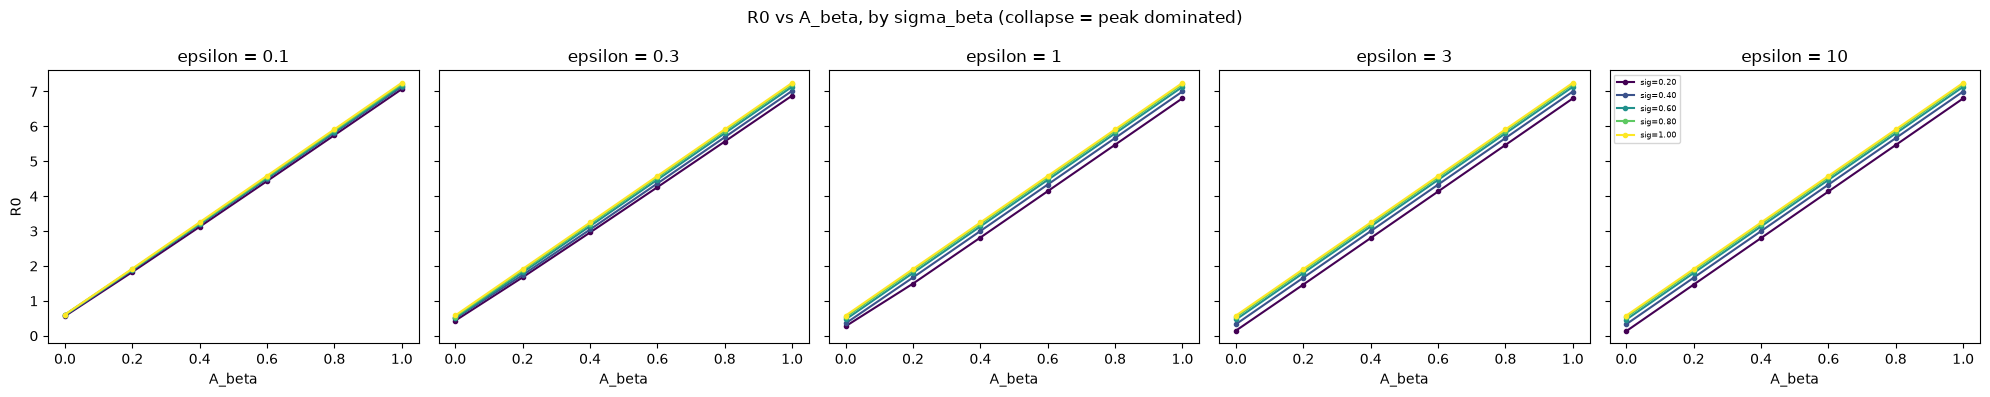

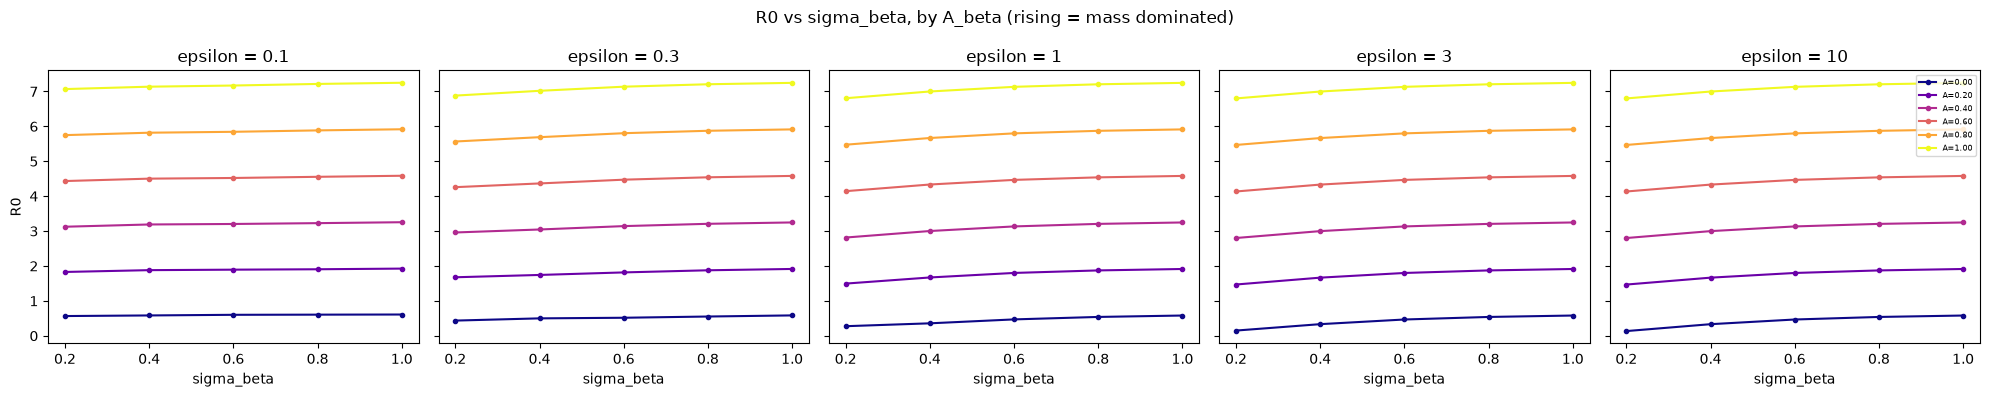

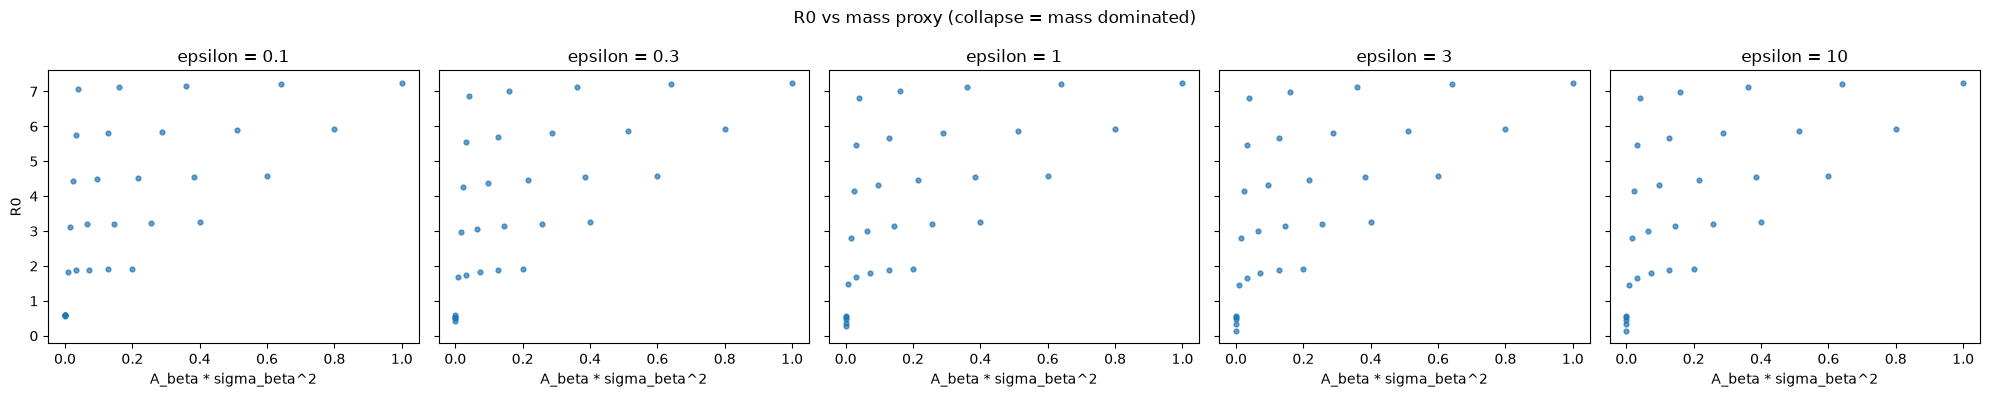

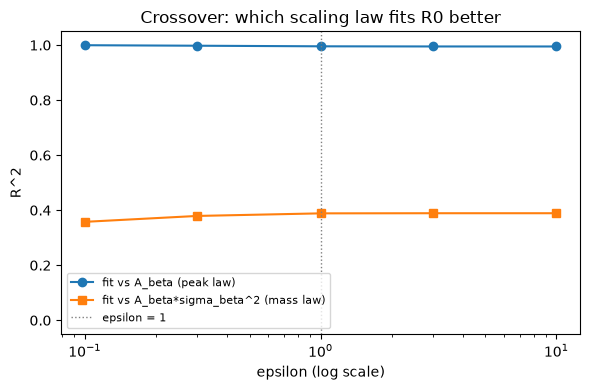

In [26]:
crossover_df = crossover_table(df)
make_all_plots(df, crossover_df, out_dir=str(output_dir))